<a href="https://colab.research.google.com/github/milansua/Projectschool/blob/main/Train_a_Food_Model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a Food Classifier


## Load and prepare Data

First we need to update the notebook to the latest version of fastai.

In [1]:
!pip install -Uqq fastai
from fastai.vision.all import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


At first we are downloading the Food Dataset, containing about 100k images of various kind of foods.
Documentation for all Datasets: https://docs.fast.ai/data.external

In [3]:
foodPath= ('/content/drive/MyDrive/Projectschool/state_dataset/train')

In [4]:
from fastai.vision.all import *
from fastai.data.transforms import get_image_files # Explicitly import get_image_files.

#How many images are we dealing with
len(get_image_files(foodPath))

8827

<Axes: >

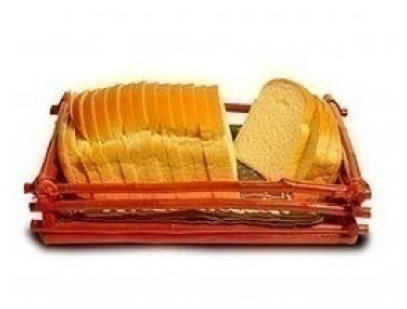

In [5]:
imag=PILImage.create(get_image_files(foodPath)[9])
imag.show()

In [ ]:
#Use Pandas to parse the JSON as a human readable table
pd.read_json('/content/drive/MyDrive/Projectschool/state_dataset/train/image_data.json')

,folder,image
0,sliced,sliced/carrot_sliced_197.jpg
1,sliced,sliced/0088.jpg
2,sliced,sliced/0711.jpg
3,sliced,sliced/0063.jpg
4,sliced,sliced/0261.jpg
...,...,...
8573,whole,whole/0097.jpg
8574,whole,whole/41.peeled-garlic.jpg
8575,whole,whole/0281.jpg
8576,whole,whole/0444.jpg


In [ ]:
import os
import json
from google.colab import drive



# STEP 2: Set your dataset directory inside Google Drive
dataset_dir = "/content/drive/MyDrive/Projectschool/state_dataset/train"  # <-- UPDATE THIS PATH

# STEP 3: Check if the path exists
if not os.path.exists(dataset_dir):
    raise FileNotFoundError(f"❌ The dataset path does not exist: {dataset_dir}")

# STEP 4: Create a list to store image paths and labels
data = []

# Loop through each folder (category) inside the dataset directory
for folder in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder)

    # Check if it's a directory
    if os.path.isdir(folder_path):
        # List all image files in the folder
        images = [img for img in os.listdir(folder_path) if img.endswith(('.jpg', '.jpeg', '.png'))]

        # Add each image with its corresponding folder (label)
        for img in images:
            data.append({"folder": folder, "image": os.path.join(folder, img)})

# STEP 5: Save the JSON file inside Google Drive
json_path = os.path.join(dataset_dir, "image_data.json")
with open(json_path, "w") as json_file:
    json.dump(data, json_file, indent=4)

print(f"✅ JSON file created: {json_path}")

# STEP 6: Download the JSON file to your local computer
from google.colab import files
files.download(json_path)


✅ JSON file created: /content/drive/MyDrive/Projectschool/state_dataset/train/image_data.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
#Deciding which foods we want to classify
labelA = 'juiced'
labelB = 'diced'
labelC = 'floured'
labelD = 'creamy_paste'
labelE = 'jullienne'
labelF = 'other'
labelG = 'peeled'
labelH = 'whole'
labelI = 'mixed'
labelJ = 'fork'
LabelK = 'spoon'
LabelL = 'knife'


**Some Data Preperation**

Next we're gonna do some preperation to make the data handling easier. It's not important that you understand the following code snippet completly.

We're just doing two things:


1.   Removing all images that don't have labelA or labelB
2.   Renaming images with labelA or labelB to have that label in their filename



In [ ]:
import os
from fastai.vision.all import get_image_files
from pathlib import Path

# Define the main dataset path
foodPath = Path("/content/drive/MyDrive/Projectschool/state_dataset/train")  # Ensure this path exists

# Loop through all image files in subdirectories
for img in get_image_files(foodPath):
    folder_name = img.parent.name  # Get the folder name
    ext = img.suffix  # Get the file extension (e.g., .jpg, .png)

    # Create the new filename with folder_name as the prefix
    new_name = f"{folder_name}-{img.name}"  # Keep original name but add folder name as prefix
    new_path = img.parent / new_name  # Full new path

    # Rename the image if the new name is different
    if img.name != new_name:
        img.rename(new_path)

print(f"✅ Renaming complete! Remaining images: {len(get_image_files(foodPath))}")






✅ Renaming complete! Remaining images: 8578


## Train Model

In [7]:
def GetLabel(fileName):
  return fileName.split('-')[0]

GetLabel("Test-734186.jpg") #Testing

'Test'

In [ ]:
from fastai.vision.all import *
from PIL import ImageFile, UnidentifiedImageError

# Allow loading truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Custom image loader that skips unreadable images
class SafePILImage(PILImage):
    @classmethod
    def create(cls, fn, **kwargs):
        try:
            return super().create(fn, **kwargs)
        except (UnidentifiedImageError, OSError) as e:
            print(f"⚠️ Skipping bad image: {fn}")
            return None  # FastAI will ignore it


In [ ]:
dblock = DataBlock(
    blocks=(ImageBlock(cls=SafePILImage), CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224)
)

dls = dblock.dataloaders("/content/drive/MyDrive/Projectschool/state_dataset/train", bs=64)


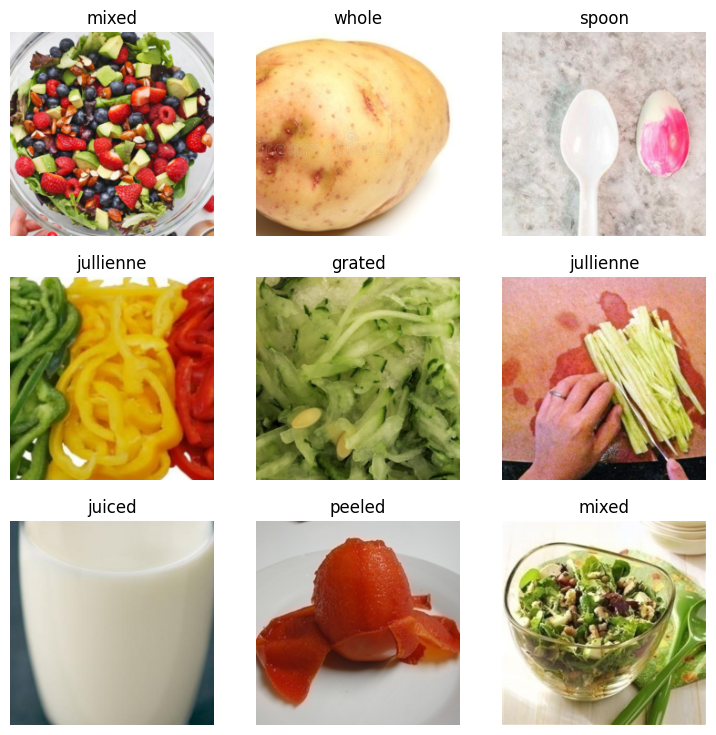

In [8]:
dls = ImageDataLoaders.from_name_func(
    foodPath, get_image_files(foodPath), valid_pct=0.2, seed=420,
    label_func=GetLabel, item_tfms=Resize(224))

dls.train.show_batch()

In [ ]:
import os
from fastai.vision.all import get_image_files
from pathlib import Path

# Define the main dataset path
foodPath = Path("/content/drive/MyDrive/Projectschool/state_dataset/train")  # Ensure this path exists

# Loop through all image files in subdirectories
for img in get_image_files(foodPath):
    folder_name = img.parent.name  # Get the folder name
    ext = img.suffix  # Get the file extension (e.g., .jpg, .png)

    # Create the new filename with folder_name as the prefix
    # Using img.stem to get the filename without extension
    new_name = f"{folder_name}-{img.stem}{ext}"
    new_path = img.parent / new_name  # Full new path

    # Rename the image if the new name is different
    if img.name != new_name:
        img.rename(new_path)

print(f"✅ Renaming complete! Remaining images: {len(get_image_files(foodPath))}")

✅ Renaming complete! Remaining images: 8828


In [ ]:
import os
print(os.path.getsize("/content/drive/MyDrive/Projectschool/state_dataset/train/fork/fork_0026.jpg"))


37096


In [9]:
print(dls.vocab)  # shows list of valid labels


['creamy_paste', 'diced', 'floured', 'fork', 'grated', 'juiced', 'jullienne', 'knife', 'mixed', 'other', 'peeled', 'sliced', 'spoon', 'whole']


In [10]:
learn = cnn_learner(dls, resnet34, metrics=error_rate, pretrained=True)
learn.fine_tune(epochs=10)

/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.870435,1.022340,0.309348,54:19


epoch,train_loss,valid_loss,error_rate,time
0,1.016459,0.756294,0.237960,01:46
1,0.743035,0.714865,0.226062,01:45
2,0.506817,0.788950,0.216431,01:43
3,0.391180,0.788624,0.212465,01:43
4,0.241810,0.820841,0.208499,01:41
5,0.153455,0.827317,0.194334,01:43
6,0.090010,0.792782,0.176771,01:42
7,0.055203,0.806480,0.171671,01:43
8,0.036809,0.778463,0.164306,01:43
9,0.023657,0.781419,0.166572,01:44


Check out this while training to have look inside a Convolutional Neural Network.

https://distill.pub/2017/feature-visualization/

## Verify Model

### Upload your own Images

Saving 0083.jpg to 0083.jpg


This is a diced.
juiced 0.951690
diced 0.000071


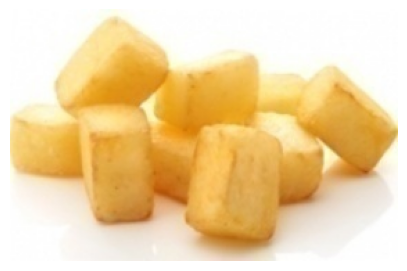

In [12]:
from google.colab import files
uploader = files.upload()

for img in uploader.items():
  uploadedImg = img[0]

img = PILImage.create(uploadedImg)
img.show()

label,_,probs = learn.predict(img)

print(f"This is a {label}.")
print(f"{labelA} {probs[1].item():.6f}")
print(f"{labelB} {probs[0].item():.6f}")

### Test using images in dataset

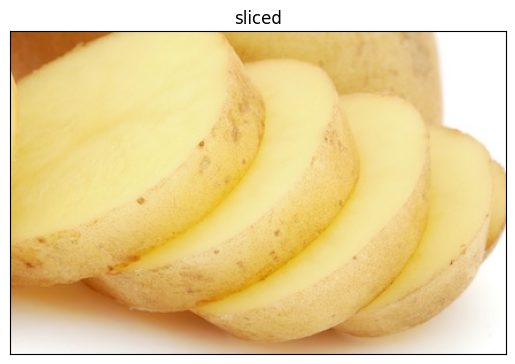

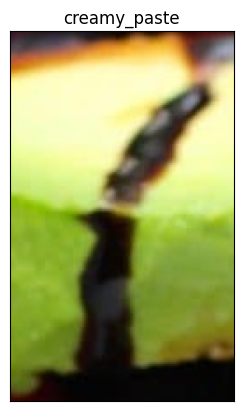

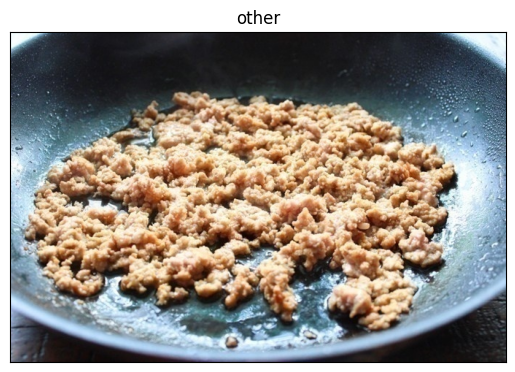

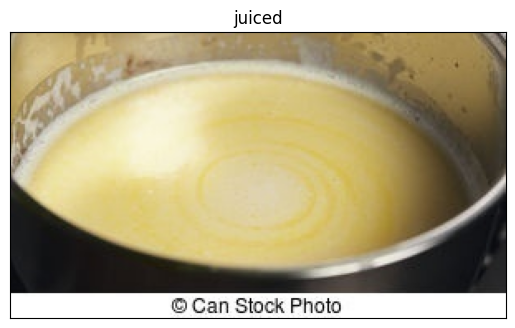

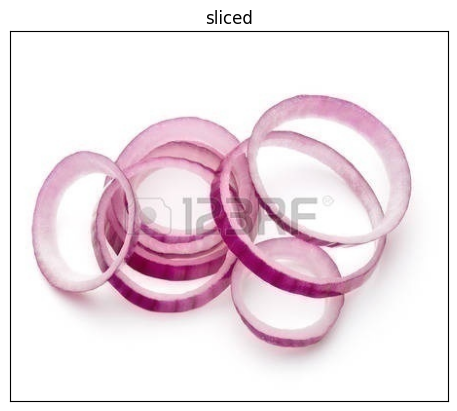

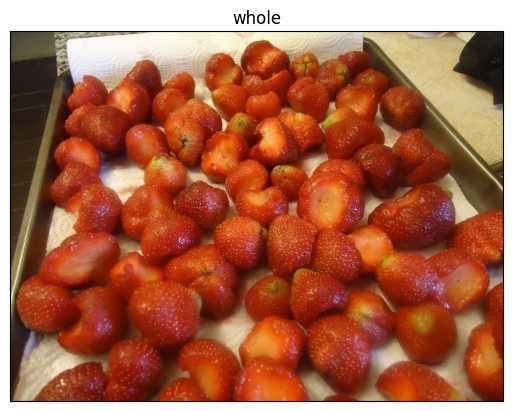

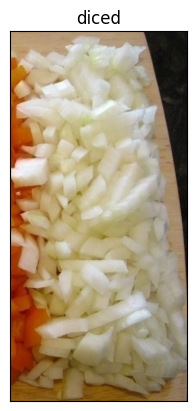

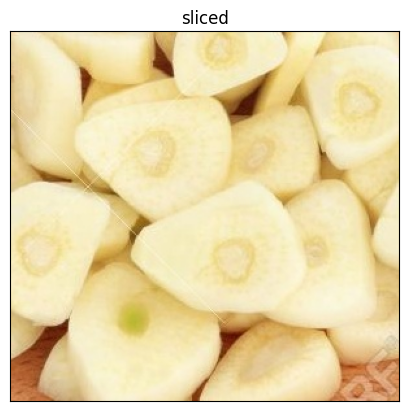

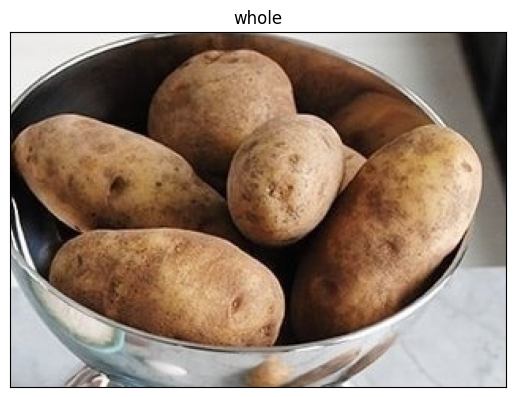

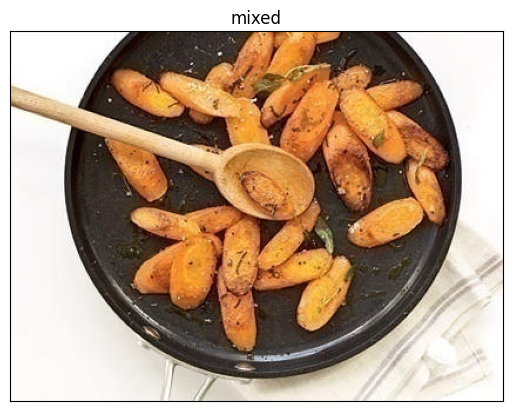

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for i in range(0,10):
  #Load random image
  randomIndex = random.randint(0, len(get_image_files(foodPath))-1)
  img = mpimg.imread(get_image_files(foodPath)[randomIndex])
  #Put into Model
  label,_,probs = learn.predict(img)

  #Create Figure using Matplotlib
  fig = plt.figure()
  ax = fig.add_subplot() #Add Subplot (For multiple images)
  imgplot = plt.imshow(img) #Add Image into Plot
  ax.set_title(label) #Set Headline to predicted label

  #Hide numbers on axes
  plt.gca().axes.get_yaxis().set_visible(False)
  plt.gca().axes.get_xaxis().set_visible(False)

### Confusion Matrix (optional)

In [21]:
print(learn.recorder.values)



[[15.998772621154785, 1.0]]


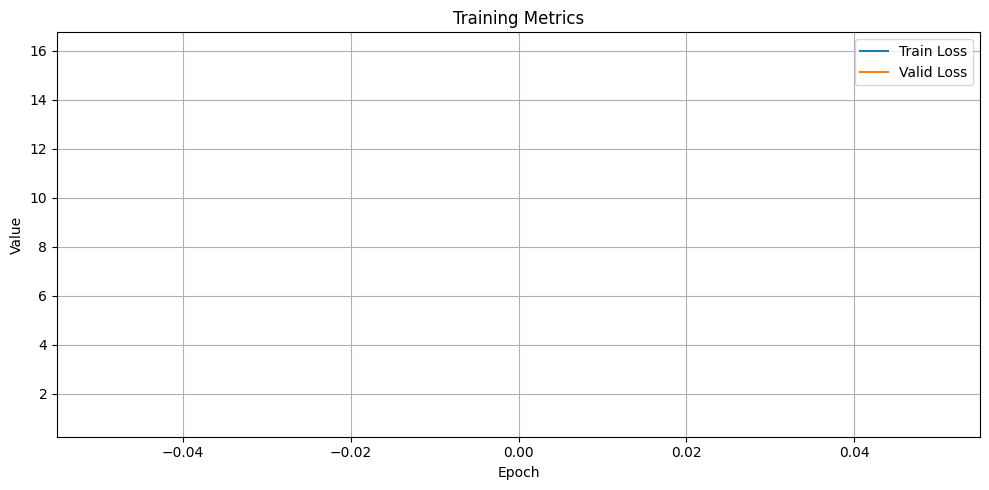

In [20]:
import matplotlib.pyplot as plt

metrics = learn.recorder.values
epochs = list(range(len(metrics)))

train_losses = [v[0] for v in metrics]
valid_losses = [v[1] for v in metrics]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, valid_losses, label='Valid Loss')

# Plot error_rate if available
if len(metrics[0]) > 2:
    error_rates = [v[2] for v in metrics]
    plt.plot(epochs, error_rates, label='Error Rate')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Metrics")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


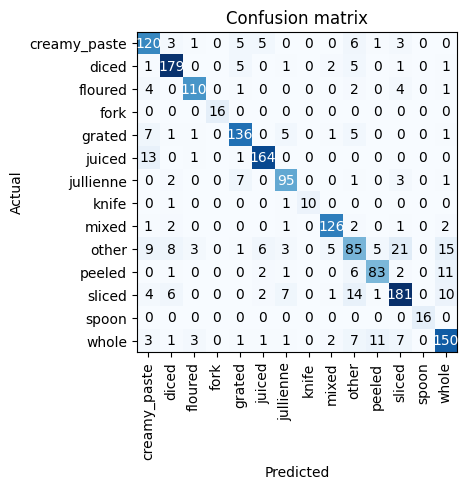

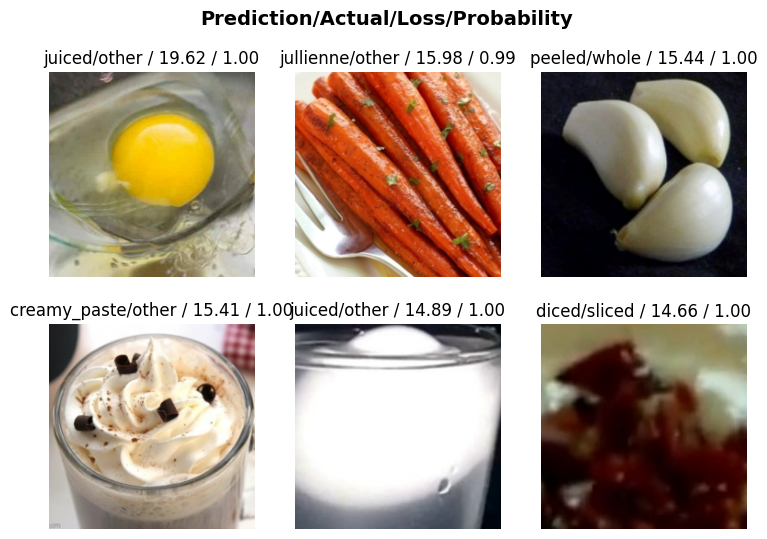

In [14]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(6)

## Deploy

In [15]:
learn.export() #exports model as 'export.pkl' by default

In [16]:
#let's grab the first pkl file we can find
modelPath = get_files(foodPath, '.pkl')[0]
modelPath

Path('/content/drive/MyDrive/Projectschool/state_dataset/train/export.pkl')

In [17]:
learn_inf = load_learner(modelPath)
learn_inf.predict(mpimg.imread(get_image_files(foodPath)[1])) #raw prediction

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


('sliced',
 tensor(11),
 tensor([1.2447e-04, 9.5977e-08, 3.6586e-06, 3.3305e-06, 9.3936e-07, 4.2492e-04,
         8.9976e-06, 4.2812e-06, 7.7619e-06, 1.3844e-04, 9.0023e-07, 9.9927e-01,
         1.2163e-05, 1.1320e-06]))

In [ ]:
learn_inf.dls.vocab #Get the labels

['creamy_paste', 'diced', 'floured', 'grated', 'juiced', 'jullienne', 'mixed', 'other', 'peeled', 'sliced', 'whole']

In [18]:
#This seems to only work properly in Chrome
from google.colab import files
files.download(modelPath)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Alternative download method
Download for non-chrome users only:

In [ ]:
shutil.move(str(modelPath), './')

This has moved the file. You should now be able to see it in the Colab File browser on the right and download it there.

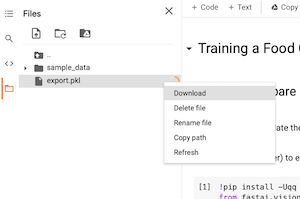